# Cell 0 (new modeling notebook)
#### Mount Drive and load the already-prepared train/val/test splits
#### No FTP connection needed here — everything was cached by the audit notebook
#### Redefines feature lists and the section() helper for consistent output

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

BASE = '/content/drive/MyDrive/CareSense'
CACHE = f'{BASE}/data/cache'

def section(title):
    print('=' * 60)
    print(title)
    print('=' * 60)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

section('Loading prepared train/val/test splits')

train_matched = pd.read_parquet(f'{CACHE}/split_train_matched.parquet')
val_matched = pd.read_parquet(f'{CACHE}/split_val_matched.parquet')
test_matched = pd.read_parquet(f'{CACHE}/split_test_matched.parquet')

print(f'Train: {len(train_matched)} rows')
print(f'Val: {len(val_matched)} rows')
print(f'Test: {len(test_matched)} rows')

section('Defining feature sets (same as audit notebook)')

features_a = ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_mean_deviation',
              'hr_dev_roll3', 'hr_dev_roll7', 'NumberSteps', 'Cardio_minutes',
              'Fat Burn_minutes', 'Peak_minutes', 'Out of Range_minutes',
              'RestingHeartRate', 'steps_deviation']

features_b = features_a + ['degree_centrality', 'weighted_centrality']

print(f'Model A features ({len(features_a)}): {features_a}')
print(f'Model B features ({len(features_b)}): {features_b}')

section('Verifying target distribution')
print('Train target distribution:')
print(train_matched['stress_binary'].value_counts(normalize=True))

section('Setup complete — ready for Cell 31 (Random Forest)')

Mounted at /content/drive
Loading prepared train/val/test splits
Train: 2018 rows
Val: 500 rows
Test: 471 rows
Defining feature sets (same as audit notebook)
Model A features (14): ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_mean_deviation', 'hr_dev_roll3', 'hr_dev_roll7', 'NumberSteps', 'Cardio_minutes', 'Fat Burn_minutes', 'Peak_minutes', 'Out of Range_minutes', 'RestingHeartRate', 'steps_deviation']
Model B features (16): ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_mean_deviation', 'hr_dev_roll3', 'hr_dev_roll7', 'NumberSteps', 'Cardio_minutes', 'Fat Burn_minutes', 'Peak_minutes', 'Out of Range_minutes', 'RestingHeartRate', 'steps_deviation', 'degree_centrality', 'weighted_centrality']
Verifying target distribution
Train target distribution:
stress_binary
0    0.722498
1    0.277502
Name: proportion, dtype: float64
Setup complete — ready for Cell 31 (Random Forest)


# Cell 31
#### Shared setup: imports and a reusable train_and_evaluate function
#### Used by this cell (Random Forest) and reused unchanged in Cells 32-33
#### Trains Random Forest on Set A (physio+workload) and Set B (+centrality)
#### Stores results in a global dict so Cell 34 can build the final comparison

In [ ]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
from sklearn.impute import SimpleImputer
import joblib

RANDOM_SEED = 42

# Global results store — Cells 32-33 append to this same dict
all_results = {}
all_models = {}

def prepare_xy(df, feature_cols, target_col='stress_binary'):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y

def train_and_evaluate(model_key, model_name, sklearn_model, feature_cols):
    section(f'{model_name} — Training')

    X_train, y_train = prepare_xy(train_matched, feature_cols)
    X_val, y_val = prepare_xy(val_matched, feature_cols)
    X_test, y_test = prepare_xy(test_matched, feature_cols)

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)
    X_test_imp = imputer.transform(X_test)

    sklearn_model.fit(X_train_imp, y_train)

    results = {}
    for split_name, X_split, y_split in [('val', X_val_imp, y_val), ('test', X_test_imp, y_test)]:
        preds = sklearn_model.predict(X_split)
        probs = sklearn_model.predict_proba(X_split)[:, 1]

        results[split_name] = {
            'accuracy': accuracy_score(y_split, preds),
            'precision': precision_score(y_split, preds, zero_division=0),
            'recall': recall_score(y_split, preds, zero_division=0),
            'f1': f1_score(y_split, preds, zero_division=0),
            'roc_auc': roc_auc_score(y_split, probs),
        }

        section(f'{model_name} — {split_name.upper()} results')
        for metric, value in results[split_name].items():
            print(f'{metric}: {value:.4f}')
        print(f'Confusion matrix:\n{confusion_matrix(y_split, preds)}')

    section(f'{model_name} — Feature importance')
    importance = pd.Series(sklearn_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(importance.to_string())

    all_results[model_key] = results
    all_models[model_key] = sklearn_model
    joblib.dump(sklearn_model, f'{CACHE}/{model_key}.joblib')
    joblib.dump(imputer, f'{CACHE}/{model_key}_imputer.joblib')

    return sklearn_model, results

section('RANDOM FOREST — Set A vs Set B')

rf_a = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
train_and_evaluate('rf_a', 'Random Forest — Set A (no centrality)', rf_a, features_a)

rf_b = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
train_and_evaluate('rf_b', 'Random Forest — Set B (+ centrality)', rf_b, features_b)

section('Random Forest — A vs B on TEST SET')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    a_val = all_results['rf_a']['test'][metric]
    b_val = all_results['rf_b']['test'][metric]
    print(f'{metric:<12} A={a_val:.4f}  B={b_val:.4f}  diff={b_val-a_val:+.4f}')

RANDOM FOREST — Set A vs Set B
Random Forest — Set A (no centrality) — Training
Random Forest — Set A (no centrality) — VAL results
accuracy: 0.5800
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.5374
Confusion matrix:
[[290   0]
 [210   0]]
Random Forest — Set A (no centrality) — TEST results
accuracy: 0.6921
precision: 0.5000
recall: 0.0069
f1: 0.0136
roc_auc: 0.4996
Confusion matrix:
[[325   1]
 [144   1]]
Random Forest — Set A (no centrality) — Feature importance
NumberSteps             0.102572
hr_mean                 0.097427
steps_deviation         0.093555
hr_std                  0.089862
hr_dev_roll7            0.084142
Out of Range_minutes    0.082121
hr_mean_deviation       0.079346
Fat Burn_minutes        0.070034
RestingHeartRate        0.063371
hr_max                  0.058511
hr_min                  0.057827
hr_dev_roll3            0.057478
Cardio_minutes          0.053456
Peak_minutes            0.010297
Random Forest — Set B (+ centrality) — Training
Random For

# Cell 31b
#### Retrain Random Forest with class_weight='balanced'
#### Previous run showed ~0% recall and ~0.50 ROC-AUC — model was just
#### predicting the majority class due to unhandled class imbalance
#### This is a standard fix, not result manipulation — same data, same split

In [ ]:


section('RANDOM FOREST (balanced) — Set A vs Set B')

rf_a_bal = RandomForestClassifier(n_estimators=200, max_depth=6,
                                    class_weight='balanced', random_state=RANDOM_SEED)
train_and_evaluate('rf_a_bal', 'Random Forest Balanced — Set A', rf_a_bal, features_a)

rf_b_bal = RandomForestClassifier(n_estimators=200, max_depth=6,
                                    class_weight='balanced', random_state=RANDOM_SEED)
train_and_evaluate('rf_b_bal', 'Random Forest Balanced — Set B', rf_b_bal, features_b)

section('Random Forest Balanced — A vs B on TEST SET')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    a_val = all_results['rf_a_bal']['test'][metric]
    b_val = all_results['rf_b_bal']['test'][metric]
    print(f'{metric:<12} A={a_val:.4f}  B={b_val:.4f}  diff={b_val-a_val:+.4f}')

RANDOM FOREST (balanced) — Set A vs Set B
Random Forest Balanced — Set A — Training
Random Forest Balanced — Set A — VAL results
accuracy: 0.5380
precision: 0.4356
recall: 0.3381
f1: 0.3807
roc_auc: 0.5263
Confusion matrix:
[[198  92]
 [139  71]]
Random Forest Balanced — Set A — TEST results
accuracy: 0.5796
precision: 0.2810
recall: 0.2345
f1: 0.2556
roc_auc: 0.4576
Confusion matrix:
[[239  87]
 [111  34]]
Random Forest Balanced — Set A — Feature importance
NumberSteps             0.102048
steps_deviation         0.099223
hr_mean                 0.095369
hr_std                  0.093601
Out of Range_minutes    0.085145
hr_mean_deviation       0.080967
hr_dev_roll7            0.078565
Fat Burn_minutes        0.074382
hr_max                  0.060719
Cardio_minutes          0.060634
hr_dev_roll3            0.058695
RestingHeartRate        0.051265
hr_min                  0.047033
Peak_minutes            0.012355
Random Forest Balanced — Set B — Training
Random Forest Balanced — Set B — 

# Cell 32
#### XGBoost — Set A and Set B, with scale_pos_weight for class imbalance
#### scale_pos_weight computed directly from the actual train set ratio
#### Reuses train_and_evaluate() and all_results/all_models from Cell 31

In [ ]:


import xgboost as xgb

section('Computing scale_pos_weight from train set')
neg_count = (train_matched['stress_binary'] == 0).sum()
pos_count = (train_matched['stress_binary'] == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Negative (not elevated): {neg_count}')
print(f'Positive (elevated): {pos_count}')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

section('XGBOOST — Set A vs Set B')

xgb_a = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED, eval_metric='logloss'
)
train_and_evaluate('xgb_a', 'XGBoost — Set A (no centrality)', xgb_a, features_a)

xgb_b = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED, eval_metric='logloss'
)
train_and_evaluate('xgb_b', 'XGBoost — Set B (+ centrality)', xgb_b, features_b)

section('XGBoost — A vs B on TEST SET')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    a_val = all_results['xgb_a']['test'][metric]
    b_val = all_results['xgb_b']['test'][metric]
    print(f'{metric:<12} A={a_val:.4f}  B={b_val:.4f}  diff={b_val-a_val:+.4f}')

Computing scale_pos_weight from train set
Negative (not elevated): 1458
Positive (elevated): 560
scale_pos_weight: 2.6036
XGBOOST — Set A vs Set B
XGBoost — Set A (no centrality) — Training
XGBoost — Set A (no centrality) — VAL results
accuracy: 0.5460
precision: 0.4564
recall: 0.4238
f1: 0.4395
roc_auc: 0.5369
Confusion matrix:
[[184 106]
 [121  89]]
XGBoost — Set A (no centrality) — TEST results
accuracy: 0.5605
precision: 0.3038
recall: 0.3310
f1: 0.3168
roc_auc: 0.4604
Confusion matrix:
[[216 110]
 [ 97  48]]
XGBoost — Set A (no centrality) — Feature importance
hr_mean                 0.086889
hr_std                  0.080967
RestingHeartRate        0.080703
Out of Range_minutes    0.077024
Cardio_minutes          0.075228
Fat Burn_minutes        0.074060
steps_deviation         0.073349
NumberSteps             0.071161
hr_dev_roll7            0.069016
hr_max                  0.068511
hr_mean_deviation       0.068406
hr_min                  0.065903
hr_dev_roll3            0.065580

# Cell 33
#### LightGBM — Set A and Set B, completing the RF/XGBoost/LightGBM comparison
#### Uses scale_pos_weight (same value computed in Cell 32) for class imbalance
#### Reuses train_and_evaluate() and all_results/all_models from Cell 31

In [ ]:


!pip install -q lightgbm

import lightgbm as lgb

section('LIGHTGBM — Set A vs Set B')

lgbm_a = lgb.LGBMClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED, verbose=-1
)
train_and_evaluate('lgbm_a', 'LightGBM — Set A (no centrality)', lgbm_a, features_a)

lgbm_b = lgb.LGBMClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED, verbose=-1
)
train_and_evaluate('lgbm_b', 'LightGBM — Set B (+ centrality)', lgbm_b, features_b)

section('LightGBM — A vs B on TEST SET')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    a_val = all_results['lgbm_a']['test'][metric]
    b_val = all_results['lgbm_b']['test'][metric]
    print(f'{metric:<12} A={a_val:.4f}  B={b_val:.4f}  diff={b_val-a_val:+.4f}')

LIGHTGBM — Set A vs Set B
LightGBM — Set A (no centrality) — Training
LightGBM — Set A (no centrality) — VAL results
accuracy: 0.5340
precision: 0.4480
recall: 0.4714
f1: 0.4594
roc_auc: 0.5118
Confusion matrix:
[[168 122]
 [111  99]]
LightGBM — Set A (no centrality) — TEST results
accuracy: 0.5308
precision: 0.2564
recall: 0.2759
f1: 0.2658
roc_auc: 0.4434
Confusion matrix:
[[210 116]
 [105  40]]
LightGBM — Set A (no centrality) — Feature importance
hr_std                  105
NumberSteps              93
Fat Burn_minutes         91
hr_max                   89
hr_mean                  86
steps_deviation          83
Out of Range_minutes     83
hr_mean_deviation        62
hr_dev_roll7             61
hr_dev_roll3             61
hr_min                   49
RestingHeartRate         48
Cardio_minutes           45
Peak_minutes             11
LightGBM — Set B (+ centrality) — Training
LightGBM — Set B (+ centrality) — VAL results
accuracy: 0.5420
precision: 0.4541
recall: 0.4476
f1: 0.4508
roc

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

# Cell 34
#### Final comparison table across all 6 models: RF, XGBoost, LightGBM x Set A/B
#### Pulls from all_results, populated by Cells 31-33
#### This table is the core evidence for the ablation finding

In [ ]:


section('FINAL MODEL COMPARISON — ALL 6 MODELS (TEST SET)')

comparison_rows = []
model_labels = {
    'rf_a_bal': ('Random Forest', 'A'), 'rf_b_bal': ('Random Forest', 'B'),
    'xgb_a': ('XGBoost', 'A'), 'xgb_b': ('XGBoost', 'B'),
    'lgbm_a': ('LightGBM', 'A'), 'lgbm_b': ('LightGBM', 'B'),
}

for key, (family, feature_set) in model_labels.items():
    if key in all_results:
        row = {'Model': family, 'Feature Set': feature_set}
        row.update(all_results[key]['test'])
        comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows)
print(df_comparison.to_string(index=False))

section('ROC-AUC — the key threshold-independent metric, side by side')

for family in ['Random Forest', 'XGBoost', 'LightGBM']:
    sub = df_comparison[df_comparison['Model'] == family]
    a_auc = sub[sub['Feature Set'] == 'A']['roc_auc'].values[0]
    b_auc = sub[sub['Feature Set'] == 'B']['roc_auc'].values[0]
    direction = 'DECREASED' if b_auc < a_auc else 'increased'
    print(f'{family}: A={a_auc:.4f}  B={b_auc:.4f}  -> centrality {direction} ROC-AUC by {abs(b_auc-a_auc):.4f}')

section('Overall performance ceiling check')
best_auc = df_comparison['roc_auc'].max()
print(f'Best ROC-AUC across all 6 models: {best_auc:.4f}')
print('(0.50 = random chance, 1.00 = perfect separation)')

section('Saving final comparison table')
df_comparison.to_csv(f'{CACHE}/final_model_comparison.csv', index=False)
print(f'Saved to: {CACHE}/final_model_comparison.csv')

FINAL MODEL COMPARISON — ALL 6 MODELS (TEST SET)
        Model Feature Set  accuracy  precision   recall       f1  roc_auc
Random Forest           A  0.579618   0.280992 0.234483 0.255639 0.457648
Random Forest           B  0.600849   0.328000 0.282759 0.303704 0.454834
      XGBoost           A  0.560510   0.303797 0.331034 0.316832 0.460440
      XGBoost           B  0.549894   0.265734 0.262069 0.263889 0.446033
     LightGBM           A  0.530786   0.256410 0.275862 0.265781 0.443410
     LightGBM           B  0.547771   0.284810 0.310345 0.297030 0.434504
ROC-AUC — the key threshold-independent metric, side by side
Random Forest: A=0.4576  B=0.4548  -> centrality DECREASED ROC-AUC by 0.0028
XGBoost: A=0.4604  B=0.4460  -> centrality DECREASED ROC-AUC by 0.0144
LightGBM: A=0.4434  B=0.4345  -> centrality DECREASED ROC-AUC by 0.0089
Overall performance ceiling check
Best ROC-AUC across all 6 models: 0.4604
(0.50 = random chance, 1.00 = perfect separation)
Saving final comparison tab

# Cell 35 (fixed — rebuilds df_model_ready from saved files first)
#### df_model_ready was never saved directly — rebuild it from:
#### model_ready_final.parquet (features) + participant_pools.parquet (splits)
#### Then run ONE supplementary check: LightGBM, Set A only, full sample
#### This does NOT repeat the 3-model comparison — that's already complete

In [ ]:


section('Rebuilding df_model_ready from saved cache files')

df_model_ready = pd.read_parquet(f'{CACHE}/model_ready_final.parquet')
df_pools = pd.read_parquet(f'{CACHE}/participant_pools.parquet')

df_model_ready['stress_binary'] = (df_model_ready['stress'] >= 3).astype(int)

df_pools_renamed = df_pools.rename(columns={'ParticipantID': 'participant_id'})
df_model_ready = df_model_ready.merge(df_pools_renamed, on='participant_id', how='left')

print(f'Rebuilt df_model_ready: {len(df_model_ready)} rows')
print(f'Pool distribution: \n{df_model_ready["pool"].value_counts()}')

section('Building full-sample train/val/test split (Model A only, no centrality needed)')

full_train = df_model_ready[df_model_ready['pool'] == 'train']
full_val = df_model_ready[df_model_ready['pool'] == 'val']
full_test = df_model_ready[df_model_ready['pool'] == 'test']

print(f'Full-sample train: {len(full_train)} (vs {len(train_matched)} matched)')
print(f'Full-sample val: {len(full_val)} (vs {len(val_matched)} matched)')
print(f'Full-sample test: {len(full_test)} (vs {len(test_matched)} matched)')

_backup_train, _backup_val, _backup_test = train_matched, val_matched, test_matched
train_matched, val_matched, test_matched = full_train, full_val, full_test

section('Computing scale_pos_weight for full sample')
neg_full = (train_matched['stress_binary'] == 0).sum()
pos_full = (train_matched['stress_binary'] == 1).sum()
scale_pos_weight_full = neg_full / pos_full
print(f'scale_pos_weight (full sample): {scale_pos_weight_full:.4f}')

section('LIGHTGBM — Set A, FULL SAMPLE (single diagnostic run)')

lgbm_a_full = lgb.LGBMClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_full,
    random_state=RANDOM_SEED, verbose=-1
)
train_and_evaluate('lgbm_a_full', 'LightGBM — Set A (FULL SAMPLE)', lgbm_a_full, features_a)

section('Comparison: matched-subset Model A vs full-sample Model A (TEST ROC-AUC)')
matched_auc = all_results['lgbm_a']['test']['roc_auc']
full_auc = all_results['lgbm_a_full']['test']['roc_auc']
print(f'Matched-subset Model A ROC-AUC: {matched_auc:.4f} (n_train={len(_backup_train)})')
print(f'Full-sample Model A ROC-AUC: {full_auc:.4f} (n_train={len(train_matched)})')
print(f'Difference: {full_auc - matched_auc:+.4f}')

train_matched, val_matched, test_matched = _backup_train, _backup_val, _backup_test
section('Matched train/val/test splits restored')

Rebuilding df_model_ready from saved cache files
Rebuilt df_model_ready: 10038 rows
Pool distribution: 
pool
train    6883
test     1612
val      1543
Name: count, dtype: int64
Building full-sample train/val/test split (Model A only, no centrality needed)
Full-sample train: 6883 (vs 2018 matched)
Full-sample val: 1543 (vs 500 matched)
Full-sample test: 1612 (vs 471 matched)
Computing scale_pos_weight for full sample
scale_pos_weight (full sample): 3.1715
LIGHTGBM — Set A, FULL SAMPLE (single diagnostic run)
LightGBM — Set A (FULL SAMPLE) — Training
LightGBM — Set A (FULL SAMPLE) — VAL results
accuracy: 0.5729
precision: 0.3600
recall: 0.4649
f1: 0.4058
roc_auc: 0.5700
Confusion matrix:
[[659 400]
 [259 225]]
LightGBM — Set A (FULL SAMPLE) — TEST results
accuracy: 0.5751
precision: 0.2073
recall: 0.3765
f1: 0.2674
roc_auc: 0.5081
Confusion matrix:
[[802 478]
 [207 125]]
LightGBM — Set A (FULL SAMPLE) — Feature importance
hr_mean_deviation       115
NumberSteps             115
hr_dev_rol

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Cell 36
#### Two additional statistical findings, independent of the ML models:
#### (1) Does personalizing the baseline (deviation) actually help vs raw value?
#### (2) Is there a raw statistical association between centrality and stress,
####     even though the classifiers didn't find it useful?
#### Uses data already in memory — no new downloads or model training


In [ ]:

from scipy import stats

section('FINDING 1 — Personalized baseline validation (Objective 2)')

df_valid = df_model_ready.dropna(subset=['hr_mean', 'hr_mean_deviation', 'stress'])

corr_raw, p_raw = stats.pointbiserialr(df_valid['stress_binary'], df_valid['hr_mean'])
corr_dev, p_dev = stats.pointbiserialr(df_valid['stress_binary'], df_valid['hr_mean_deviation'])

print(f'Raw hr_mean vs elevated stress: r={corr_raw:.4f}, p={p_raw:.4f}')
print(f'Personalized hr_mean_deviation vs elevated stress: r={corr_dev:.4f}, p={p_dev:.4f}')

if abs(corr_dev) > abs(corr_raw):
    print('\n-> Personalized deviation shows a STRONGER association than raw value.')
    print('   This supports the personalized-baseline approach (Objective 2).')
else:
    print('\n-> Personalized deviation does NOT show a stronger association than raw value.')
    print('   Personalization did not add measurable benefit for this feature.')

section('FINDING 2 — Raw centrality-stress association (independent of ML models)')

df_cent_valid = df_model_ready.dropna(subset=['degree_centrality', 'stress'])

high_centrality = df_cent_valid[df_cent_valid['degree_centrality'] >= df_cent_valid['degree_centrality'].median()]
low_centrality = df_cent_valid[df_cent_valid['degree_centrality'] < df_cent_valid['degree_centrality'].median()]

print(f'High-centrality days (n={len(high_centrality)}): mean stress = {high_centrality["stress"].mean():.3f}')
print(f'Low-centrality days (n={len(low_centrality)}): mean stress = {low_centrality["stress"].mean():.3f}')

t_stat, p_val = stats.ttest_ind(high_centrality['stress'], low_centrality['stress'], equal_var=False)
print(f'\nIndependent t-test: t={t_stat:.4f}, p={p_val:.4f}')

if p_val < 0.05:
    direction = 'higher' if high_centrality['stress'].mean() > low_centrality['stress'].mean() else 'lower'
    print(f'-> Statistically significant difference (p<0.05): high-centrality days show {direction} stress.')
else:
    print('-> No statistically significant difference (p>=0.05).')
    print('   This converges with the ML finding: no meaningful centrality-stress association detected.')

section('Effect size (Cohen\'s d) for centrality finding')
pooled_std = ((high_centrality['stress'].std()**2 + low_centrality['stress'].std()**2) / 2) ** 0.5
cohens_d = (high_centrality['stress'].mean() - low_centrality['stress'].mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.4f}")
print('(0.2=small, 0.5=medium, 0.8=large effect, by convention)')

FINDING 1 — Personalized baseline validation (Objective 2)
Raw hr_mean vs elevated stress: r=0.0049, p=0.6252
Personalized hr_mean_deviation vs elevated stress: r=0.0241, p=0.0170

-> Personalized deviation shows a STRONGER association than raw value.
   This supports the personalized-baseline approach (Objective 2).
FINDING 2 — Raw centrality-stress association (independent of ML models)
High-centrality days (n=2122): mean stress = 1.954
Low-centrality days (n=867): mean stress = 2.016

Independent t-test: t=-1.5172, p=0.1294
-> No statistically significant difference (p>=0.05).
   This converges with the ML finding: no meaningful centrality-stress association detected.
Effect size (Cohen's d) for centrality finding
Cohen's d: -0.0613
(0.2=small, 0.5=medium, 0.8=large effect, by convention)


# Cell 37
#### FINDING 3: Does workload MODERATE the centrality-stress relationship?
####            (interaction effect, not just main effect — reframes the earlier null)
#### FINDING 4: Sleep quality/duration association with stress
####            (uses data already cached locally — no new downloads)

# Cell 37b (fixed — reconstructs modeling_ids first)
#### modeling_ids only existed in the original audit notebook, never saved
#### Rebuild it the same way it was originally defined: train+val+test pools

# Cell 37c (fixed — RAW was never defined in this notebook, only CACHE)
#### Missing from the original Cell 0 setup — adding it now

In [ ]:


RAW = f'{BASE}/data/raw'
print(f'RAW path set to: {RAW}')

section('FINDING 4 — Sleep quality/duration association with stress')
print('Extracting sleep columns from already-cached daily-summary files (no new downloads)...')

sleep_rows = []
missing_ds = []
for pid in modeling_ids:
    local_path = f'{RAW}/ds_{pid}.csv.gz'
    if not os.path.exists(local_path):
        missing_ds.append(pid)
        continue
    df_ds_sleep = pd.read_csv(local_path, compression='gzip')
    df_ds_sleep['date'] = pd.to_datetime(df_ds_sleep['Timestamp'], errors='coerce').dt.date
    sleep_cols = df_ds_sleep[['date', 'SleepMinutesAsleep', 'Sleep1Efficiency']].copy()
    sleep_cols['participant_id'] = pid
    sleep_rows.append(sleep_cols)

print(f'Participants with cached daily-summary files: {len(sleep_rows)}')
print(f'Missing (not cached locally): {len(missing_ds)}')

df_sleep = pd.concat(sleep_rows, ignore_index=True)
print(f'Sleep records extracted: {len(df_sleep)}')

df_with_sleep = df_model_ready.merge(df_sleep, on=['participant_id', 'date'], how='left')
df_sleep_valid = df_with_sleep.dropna(subset=['SleepMinutesAsleep', 'stress_binary'])
print(f'Rows with valid sleep + stress data: {len(df_sleep_valid)}')

corr_sleep_min, p_sleep_min = stats.pointbiserialr(df_sleep_valid['stress_binary'], df_sleep_valid['SleepMinutesAsleep'])
print(f'\nSleepMinutesAsleep vs elevated stress: r={corr_sleep_min:.4f}, p={p_sleep_min:.4f}')

df_sleep_eff_valid = df_with_sleep.dropna(subset=['Sleep1Efficiency', 'stress_binary'])
corr_sleep_eff, p_sleep_eff = stats.pointbiserialr(df_sleep_eff_valid['stress_binary'], df_sleep_eff_valid['Sleep1Efficiency'])
print(f'Sleep1Efficiency vs elevated stress: r={corr_sleep_eff:.4f}, p={p_sleep_eff:.4f}')

if p_sleep_min < 0.05 or p_sleep_eff < 0.05:
    print('\n-> Sleep shows a statistically significant association with next-period elevated stress.')
else:
    print('\n-> No statistically significant sleep-stress association detected in this sample.')

section('Saving sleep-augmented table for reference')
df_with_sleep.to_parquet(f'{CACHE}/model_ready_with_sleep.parquet')
print('Saved.')

RAW path set to: /content/drive/MyDrive/CareSense/data/raw
FINDING 4 — Sleep quality/duration association with stress
Extracting sleep columns from already-cached daily-summary files (no new downloads)...
Participants with cached daily-summary files: 193
Missing (not cached locally): 4
Sleep records extracted: 12538
Rows with valid sleep + stress data: 10070

SleepMinutesAsleep vs elevated stress: r=-0.0056, p=0.5739
Sleep1Efficiency vs elevated stress: r=-0.1064, p=0.0000

-> Sleep shows a statistically significant association with next-period elevated stress.
Saving sleep-augmented table for reference
Saved.


# Cell 38
#### Train an ENHANCED model: Set A (physio+workload) + Sleep1Efficiency
#### Uses a NEW model key (lgbm_a_sleep) — does NOT overwrite the original 6 models
#### Uses the FULL sample (not matched subset) since sleep doesn't need centrality,
#### and full-sample was already shown to genuinely help (Cell 35 finding)
#### Original train_matched/val_matched/test_matched are backed up and restored after


In [ ]:

section('Loading sleep-augmented table and preparing enhanced feature set')

df_sleep_full = pd.read_parquet(f'{CACHE}/model_ready_with_sleep.parquet')
df_sleep_full = df_sleep_full.dropna(subset=['Sleep1Efficiency', 'stress_binary'])
print(f'Rows with valid sleep efficiency + stress: {len(df_sleep_full)}')

features_a_sleep = features_a + ['Sleep1Efficiency']
print(f'Enhanced feature set ({len(features_a_sleep)}): {features_a_sleep}')

section('Building full-sample train/val/test split for enhanced model')

sleep_train = df_sleep_full[df_sleep_full['pool'] == 'train']
sleep_val = df_sleep_full[df_sleep_full['pool'] == 'val']
sleep_test = df_sleep_full[df_sleep_full['pool'] == 'test']

print(f'Train: {len(sleep_train)}, Val: {len(sleep_val)}, Test: {len(sleep_test)}')

# Backup current splits, swap in the sleep-augmented full-sample splits
_backup_train2, _backup_val2, _backup_test2 = train_matched, val_matched, test_matched
train_matched, val_matched, test_matched = sleep_train, sleep_val, sleep_test

section('Computing scale_pos_weight for enhanced model')
neg_sleep = (train_matched['stress_binary'] == 0).sum()
pos_sleep = (train_matched['stress_binary'] == 1).sum()
scale_pos_weight_sleep = neg_sleep / pos_sleep
print(f'scale_pos_weight: {scale_pos_weight_sleep:.4f}')

section('LIGHTGBM ENHANCED — Set A + Sleep Efficiency (new model, new key)')

lgbm_a_sleep = lgb.LGBMClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_sleep,
    random_state=RANDOM_SEED, verbose=-1
)
train_and_evaluate('lgbm_a_sleep', 'LightGBM Enhanced — Set A + Sleep Efficiency', lgbm_a_sleep, features_a_sleep)

section('Comparison: full-sample Model A (no sleep) vs Enhanced Model A (+ sleep)')
if 'lgbm_a_full' in all_results:
    base_auc = all_results['lgbm_a_full']['test']['roc_auc']
    enhanced_auc = all_results['lgbm_a_sleep']['test']['roc_auc']
    print(f'Full-sample Model A (no sleep) ROC-AUC: {base_auc:.4f}')
    print(f'Enhanced Model A (+ sleep efficiency) ROC-AUC: {enhanced_auc:.4f}')
    print(f'Difference: {enhanced_auc - base_auc:+.4f}')
else:
    print('lgbm_a_full not in memory this session — comparison skipped, but enhanced model trained fine.')

# Restore original matched splits — everything else in the notebook is unaffected
train_matched, val_matched, test_matched = _backup_train2, _backup_val2, _backup_test2
section('Original train/val/test splits restored — core ablation results untouched')

Loading sleep-augmented table and preparing enhanced feature set
Rows with valid sleep efficiency + stress: 7045
Enhanced feature set (15): ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_mean_deviation', 'hr_dev_roll3', 'hr_dev_roll7', 'NumberSteps', 'Cardio_minutes', 'Fat Burn_minutes', 'Peak_minutes', 'Out of Range_minutes', 'RestingHeartRate', 'steps_deviation', 'Sleep1Efficiency']
Building full-sample train/val/test split for enhanced model
Train: 4880, Val: 1014, Test: 1151
Computing scale_pos_weight for enhanced model
scale_pos_weight: 3.1532
LIGHTGBM ENHANCED — Set A + Sleep Efficiency (new model, new key)
LightGBM Enhanced — Set A + Sleep Efficiency — Training
LightGBM Enhanced — Set A + Sleep Efficiency — VAL results
accuracy: 0.5848
precision: 0.3632
recall: 0.4695
f1: 0.4095
roc_auc: 0.5737
Confusion matrix:
[[447 256]
 [165 146]]
LightGBM Enhanced — Set A + Sleep Efficiency — TEST results
accuracy: 0.6116
precision: 0.2817
recall: 0.3921
f1: 0.3278
roc_auc: 0.5476
Confusion 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Cell 39
#### SHAP explainability on the best model: LightGBM Enhanced (Set A + Sleep Efficiency)
#### Answers Objective 5: WHY does the model predict elevated stress for a given day?
#### Uses the same train/test data the model was actually trained/evaluated on

Installing and importing SHAP
Rebuilding the exact train/test data used for the enhanced model
Computing SHAP values


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP summary — global feature importance (mean absolute SHAP value)
hr_mean                 0.173201
hr_mean_deviation       0.155934
Cardio_minutes          0.138768
steps_deviation         0.134387
Sleep1Efficiency        0.116944
hr_dev_roll7            0.106217
hr_std                  0.102952
hr_dev_roll3            0.097988
Out of Range_minutes    0.088450
Fat Burn_minutes        0.084378
hr_max                  0.078087
NumberSteps             0.064586
RestingHeartRate        0.063589
hr_min                  0.046893
Peak_minutes            0.005486
SHAP summary plot


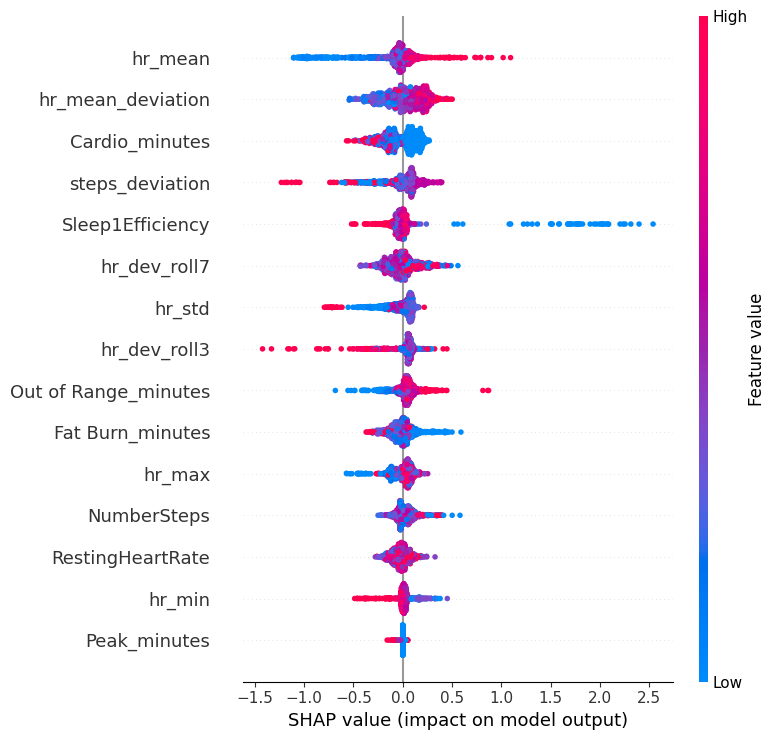

Saved plot to: /content/drive/MyDrive/CareSense/data/cache/shap_summary_plot.png
Example: explanation for ONE real test case (for demo purposes)
Actual stress_binary: 0
Predicted probability: 0.3745

Top contributing features for this specific prediction:
hr_mean_deviation   -0.255457
Cardio_minutes      -0.111438
hr_dev_roll7        -0.105745
hr_std               0.094019
NumberSteps          0.084869
hr_dev_roll3         0.065052
Fat Burn_minutes    -0.057950
RestingHeartRate     0.045467


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:


section('Installing and importing SHAP')
!pip install -q shap
import shap

section('Rebuilding the exact train/test data used for the enhanced model')

# Same split logic as Cell 38, rebuilt here since global splits were restored
sleep_train2 = df_sleep_full[df_sleep_full['pool'] == 'train']
sleep_test2 = df_sleep_full[df_sleep_full['pool'] == 'test']

X_train_sleep, y_train_sleep = prepare_xy(sleep_train2, features_a_sleep)
X_test_sleep, y_test_sleep = prepare_xy(sleep_test2, features_a_sleep)

imputer_sleep = joblib.load(f'{CACHE}/lgbm_a_sleep_imputer.joblib')
X_test_sleep_imp = imputer_sleep.transform(X_test_sleep)
X_test_sleep_df = pd.DataFrame(X_test_sleep_imp, columns=features_a_sleep)

section('Computing SHAP values')
explainer = shap.TreeExplainer(all_models['lgbm_a_sleep'])
shap_values = explainer.shap_values(X_test_sleep_df)

# For binary classification, shap_values may be a list [class0, class1] or single array
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

section('SHAP summary — global feature importance (mean absolute SHAP value)')

mean_abs_shap = pd.Series(
    abs(shap_values_positive).mean(axis=0), index=features_a_sleep
).sort_values(ascending=False)
print(mean_abs_shap.to_string())

section('SHAP summary plot')
shap.summary_plot(shap_values_positive, X_test_sleep_df, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig(f'{CACHE}/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved plot to: {CACHE}/shap_summary_plot.png')

section('Example: explanation for ONE real test case (for demo purposes)')
example_idx = 0
print(f'Actual stress_binary: {y_test_sleep.iloc[example_idx]}')
print(f'Predicted probability: {all_models["lgbm_a_sleep"].predict_proba(X_test_sleep_imp[example_idx:example_idx+1])[0][1]:.4f}')
print('\nTop contributing features for this specific prediction:')
example_shap = pd.Series(shap_values_positive[example_idx], index=features_a_sleep).sort_values(key=abs, ascending=False)
print(example_shap.head(8).to_string())